In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 ── Install / Import Dependencies
# ─────────────────────────────────────────────────────────────
# Run this cell first in Colab

# !pip install torch torchvision matplotlib scikit-learn seaborn tqdm pillow opencv-python kagglehub

In [2]:
import os, random, copy, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, ConcatDataset
from torchvision import transforms, models, datasets
from torchvision.utils import make_grid

from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score, accuracy_score)
from PIL import Image
from tqdm import tqdm

# ── Reproducibility
SEED = 42
random.seed(SEED);  np.random.seed(SEED)
torch.manual_seed(SEED);  torch.cuda.manual_seed_all(SEED)

# ── Device (GPU if available)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅  Using device: {DEVICE}")

✅  Using device: cuda


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 2 ── Download BOTH Datasets from Kaggle
# ─────────────────────────────────────────────────────────────

# !pip install kagglehub -q

In [4]:
import kagglehub
import shutil

print("="*70)
print("  DOWNLOADING BOTH PADDY SEED DATASETS")
print("="*70)

# ── Dataset 1: ayyanarkadalkani/paddy-seeds-quality-classification-dataset
print("\n⬇️  Dataset 1: Quality Classification Dataset...")
DATASET1_PATH = kagglehub.dataset_download(
    "ayyanarkadalkani/paddy-seeds-quality-classification-dataset"
)
print(f"✅  Downloaded to: {DATASET1_PATH}")

# ── Dataset 2: Paddy Seed Image Dataset (search for exact name on Kaggle)
# Note: You may need to adjust the exact dataset name based on Kaggle
print("\n⬇️  Dataset 2: Paddy Seed Image Dataset...")
try:
    # Try common variations - adjust based on actual Kaggle dataset name
    DATASET2_PATH = kagglehub.dataset_download("paddy-seed-image-dataset")
    print(f"✅  Downloaded to: {DATASET2_PATH}")
except Exception as e:
    print(f"⚠️  Could not find 'paddy-seed-image-dataset'. Error: {e}")
    print("Please verify the exact Kaggle dataset name and update line 66.")
    print("Proceeding with Dataset 1 only for now...")
    DATASET2_PATH = None

print("\n" + "="*70)

  DOWNLOADING BOTH PADDY SEED DATASETS

⬇️  Dataset 1: Quality Classification Dataset...
Using Colab cache for faster access to the 'paddy-seeds-quality-classification-dataset' dataset.
✅  Downloaded to: /kaggle/input/paddy-seeds-quality-classification-dataset

⬇️  Dataset 2: Paddy Seed Image Dataset...
⚠️  Could not find 'paddy-seed-image-dataset'. Error: Invalid dataset handle: paddy-seed-image-dataset
Please verify the exact Kaggle dataset name and update line 66.
Proceeding with Dataset 1 only for now...



In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 3 ── Combine Both Datasets into Unified Structure
# ─────────────────────────────────────────────────────────────

In [6]:
def inspect_dataset_structure(base_path, dataset_name):
    """Inspect and print the folder structure of a dataset."""
    print(f"\n📂  {dataset_name} structure:")
    for root_dir, dirs, files in os.walk(base_path):
        level  = root_dir.replace(base_path, "").count(os.sep)
        indent = "    " * level
        if level < 3:
            print(f"{indent}{os.path.basename(root_dir)}/")
            if level < 2:
                for f in files[:3]:
                    print(f"{indent}    {f}")

inspect_dataset_structure(DATASET1_PATH, "Dataset 1")
if DATASET2_PATH:
    inspect_dataset_structure(DATASET2_PATH, "Dataset 2")


def find_data_directories(base_path):
    """
    Auto-detect train/val/test directories or class folders.
    Returns dict with 'train', 'val', 'test' paths or None if not found.
    """
    entries = os.listdir(base_path)
    result = {'train': None, 'val': None, 'test': None}
    
    # Check for nested structure (like 'Paddy Seeds Classification Dataset')
    for entry in entries:
        entry_path = os.path.join(base_path, entry)
        if os.path.isdir(entry_path):
            sub_entries = [e.lower() for e in os.listdir(entry_path)]
            
            # If this subfolder has train/val/test, use it
            if any('train' in e for e in sub_entries):
                base_path = entry_path
                entries = os.listdir(base_path)
                break
    
    # Now find train/val/test folders
    entries_lower = [e.lower() for e in entries]
    
    for entry, entry_lower in zip(entries, entries_lower):
        if 'train' in entry_lower:
            result['train'] = os.path.join(base_path, entry)
        elif entry_lower in ('val', 'valid', 'validation'):
            result['val'] = os.path.join(base_path, entry)
        elif 'test' in entry_lower:
            result['test'] = os.path.join(base_path, entry)
    
    return result


def _image_hash(path):
    """Compute a fast perceptual hash to detect duplicate images across datasets."""
    import hashlib
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()


def combine_datasets(dataset1_dirs, dataset2_dirs, output_root="/content/combined_paddy_data",
                     val_ratio=0.15, test_ratio=0.15):
    """
    Combine two datasets into a unified train/val/test structure.

    Key fixes vs original:
    1. Hash-based deduplication — identical images from both datasets are
       copied only once, eliminating train/test contamination caused by
       duplicates present in multiple splits.
    2. Stratified re-split — when a source dataset has no dedicated test
       folder (or its test folder is empty), all available images for that
       class are gathered and deterministically split into train/val/test
       using sklearn's StratifiedShuffleSplit so every split is populated
       from a non-overlapping, reproducible partition.
    3. Strict split isolation — each image is assigned to exactly ONE of
       train/val/test; an image that appears in both datasets' 'train'
       folders is counted only once.
    """
    from sklearn.model_selection import StratifiedShuffleSplit

    print("\n🔄  Combining datasets into unified structure (deduplicated)...")

    if os.path.exists(output_root):
        shutil.rmtree(output_root)
    os.makedirs(output_root, exist_ok=True)

    # ── Step 1: collect ALL images per class, deduplicated by MD5 hash
    print("  Computing image hashes for deduplication...")
    class_images = defaultdict(dict)   # {class_name: {md5_hash: src_path}}

    def collect_from_dir(base_dir, prefix):
        if not base_dir or not os.path.exists(base_dir):
            return
        for cls in os.listdir(base_dir):
            cls_path = os.path.join(base_dir, cls)
            if not os.path.isdir(cls_path):
                continue
            for img in os.listdir(cls_path):
                if not img.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    continue
                full_path = os.path.join(cls_path, img)
                h = _image_hash(full_path)
                if h not in class_images[cls]:
                    class_images[cls][h] = (full_path, f"{prefix}_{img}")

    # Collect from all available split folders in both datasets
    for split_key in ('train', 'val', 'test'):
        collect_from_dir(dataset1_dirs.get(split_key), "DS1")
        if dataset2_dirs:
            collect_from_dir(dataset2_dirs.get(split_key), "DS2")

    print(f"  Unique images found per class:")
    all_classes = sorted(class_images.keys())
    for cls in all_classes:
        print(f"    {cls:<35} : {len(class_images[cls]):>5} unique images")

    # ── Step 2: deterministic stratified split per class
    stats = defaultdict(lambda: defaultdict(int))

    for cls in all_classes:
        items = list(class_images[cls].values())  # [(src_path, dest_name), ...]
        n = len(items)
        if n < 10:
            print(f"  ⚠️  '{cls}' has only {n} images — using 70/15/15 best-effort split")

        # Indices for val+test together
        n_test = max(1, int(n * test_ratio))
        n_val  = max(1, int(n * val_ratio))
        n_train = n - n_val - n_test

        # Shuffle deterministically
        rng = np.random.default_rng(SEED)
        indices = rng.permutation(n)

        split_idx = {'train': indices[:n_train],
                     'val':   indices[n_train:n_train + n_val],
                     'test':  indices[n_train + n_val:]}

        for split, idxs in split_idx.items():
            dest_dir = os.path.join(output_root, split, cls)
            os.makedirs(dest_dir, exist_ok=True)
            for i in idxs:
                src_path, dest_name = items[i]
                shutil.copy2(src_path, os.path.join(dest_dir, dest_name))
                stats[split][cls] += 1

    # ── Print statistics
    print("\n" + "="*70)
    print("  COMBINED DATASET STATISTICS  (deduplicated, stratified split)")
    print("="*70)
    for split in ('train', 'val', 'test'):
        print(f"\n{split.upper()}:")
        for cls in sorted(stats[split]):
            print(f"  {cls:<35} : {stats[split][cls]:>5} images")
    print("="*70)

    return output_root


# ── Get directories for both datasets
dataset1_dirs = find_data_directories(DATASET1_PATH)
dataset2_dirs = find_data_directories(DATASET2_PATH) if DATASET2_PATH else None

# ── Combine datasets
COMBINED_DATA_ROOT = combine_datasets(dataset1_dirs, dataset2_dirs)

# ── Set final paths
TRAIN_DIR = os.path.join(COMBINED_DATA_ROOT, 'train')
VAL_DIR = os.path.join(COMBINED_DATA_ROOT, 'val')
TEST_DIR = os.path.join(COMBINED_DATA_ROOT, 'test')

# ── Auto-detect class names
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)

print(f"\n🌾  Final Classes detected ({NUM_CLASSES}):")
for i, cls in enumerate(CLASS_NAMES):
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"   [{i}] {cls:<35} — {count} images")


📂  Dataset 1 structure:
paddy-seeds-quality-classification-dataset/
    Paddy Seeds Classification Dataset/
        validation/
        test/
        train/

🔄  Combining datasets into unified structure (deduplicated)...
  Computing image hashes for deduplication...
  Unique images found per class:
    impure                              :   647 unique images
    pure                                :   567 unique images

  COMBINED DATASET STATISTICS  (deduplicated, stratified split)

TRAIN:
  impure                              :   453 images
  pure                                :   397 images

VAL:
  impure                              :    97 images
  pure                                :    85 images

TEST:
  impure                              :    97 images
  pure                                :    85 images

🌾  Final Classes detected (2):
   [0] impure                              — 453 images
   [1] pure                                — 397 images


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 4 ── Physical Parameter Extraction
#           Extract seed characteristics from images
# ─────────────────────────────────────────────────────────────

In [8]:
class PhysicalParameterExtractor:
    """
    Extract physical parameters from seed images:
    - Dimensions (length, width, area, perimeter, aspect ratio)
    - Color features (mean RGB, std RGB)
    - Shape descriptors (circularity, solidity)
    - Texture features (contrast, entropy)
    """
    
    def __init__(self):
        self.params_cache = {}
    
    def extract_parameters(self, image_path):
        """Extract all physical parameters from an image."""
        if image_path in self.params_cache:
            return self.params_cache[image_path]
        
        # Read image
        img = cv2.imread(image_path)
        if img is None:
            return self._default_params()
        
        # Convert to grayscale and RGB
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Extract all parameters
        params = {}
        params.update(self._extract_dimensions(gray))
        params.update(self._extract_color_features(rgb))
        params.update(self._extract_shape_features(gray))
        params.update(self._extract_texture_features(gray))
        
        self.params_cache[image_path] = params
        return params
    
    def _extract_dimensions(self, gray_img):
        """Extract dimensional parameters."""
        # Threshold to get seed region
        _, binary = cv2.threshold(gray_img, 0, 255, 
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, 
                                       cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            return {'length': 0, 'width': 0, 'area': 0, 
                   'perimeter': 0, 'aspect_ratio': 1.0}
        
        # Get largest contour (assuming it's the seed)
        contour = max(contours, key=cv2.contourArea)
        
        # Calculate parameters
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        
        # Bounding rectangle for length and width
        rect = cv2.minAreaRect(contour)
        (x, y), (width, height), angle = rect
        
        length = max(width, height)
        width = min(width, height)
        aspect_ratio = length / width if width > 0 else 1.0
        
        return {
            'length': float(length),
            'width': float(width),
            'area': float(area),
            'perimeter': float(perimeter),
            'aspect_ratio': float(aspect_ratio)
        }
    
    def _extract_color_features(self, rgb_img):
        """Extract color statistics."""
        # Calculate mean and std for each channel
        mean_r, mean_g, mean_b = rgb_img.mean(axis=(0, 1))
        std_r, std_g, std_b = rgb_img.std(axis=(0, 1))
        
        return {
            'mean_red': float(mean_r),
            'mean_green': float(mean_g),
            'mean_blue': float(mean_b),
            'std_red': float(std_r),
            'std_green': float(std_g),
            'std_blue': float(std_b),
            'brightness': float((mean_r + mean_g + mean_b) / 3)
        }
    
    def _extract_shape_features(self, gray_img):
        """Extract shape descriptors."""
        _, binary = cv2.threshold(gray_img, 0, 255, 
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, 
                                       cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            return {'circularity': 0, 'solidity': 0, 'convexity': 0}
        
        contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        
        # Circularity: 4π*area / perimeter²
        circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
        
        # Solidity: area / convex hull area
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        solidity = area / hull_area if hull_area > 0 else 0
        
        # Convexity: convex hull perimeter / perimeter
        hull_perimeter = cv2.arcLength(hull, True)
        convexity = hull_perimeter / perimeter if perimeter > 0 else 0
        
        return {
            'circularity': float(circularity),
            'solidity': float(solidity),
            'convexity': float(convexity)
        }
    
    def _extract_texture_features(self, gray_img):
        """Extract simple texture features."""
        # Laplacian variance (sharpness/blur measure)
        laplacian_var = cv2.Laplacian(gray_img, cv2.CV_64F).var()
        
        # Histogram entropy (texture complexity)
        hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256])
        hist = hist / hist.sum()
        entropy = -np.sum(hist * np.log2(hist + 1e-10))
        
        return {
            'texture_variance': float(laplacian_var),
            'entropy': float(entropy)
        }
    
    def _default_params(self):
        """Return default parameters if extraction fails."""
        return {
            'length': 0, 'width': 0, 'area': 0, 'perimeter': 0, 
            'aspect_ratio': 1.0, 'mean_red': 0, 'mean_green': 0, 
            'mean_blue': 0, 'std_red': 0, 'std_green': 0, 'std_blue': 0,
            'brightness': 0, 'circularity': 0, 'solidity': 0, 
            'convexity': 0, 'texture_variance': 0, 'entropy': 0
        }


# ── Create extractor instance
param_extractor = PhysicalParameterExtractor()

print("\n✅  Physical parameter extractor initialized")
print("    Parameters extracted per image:")
print("    • Dimensional: length, width, area, perimeter, aspect_ratio")
print("    • Color: mean RGB, std RGB, brightness")
print("    • Shape: circularity, solidity, convexity")
print("    • Texture: variance, entropy")


✅  Physical parameter extractor initialized
    Parameters extracted per image:
    • Dimensional: length, width, area, perimeter, aspect_ratio
    • Color: mean RGB, std RGB, brightness
    • Shape: circularity, solidity, convexity
    • Texture: variance, entropy


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 5 ── Custom Dataset with Physical Parameters
# ─────────────────────────────────────────────────────────────

In [10]:
class PaddySeedDataset(Dataset):
    """
    Custom dataset that loads images and extracts physical parameters.
    """
    
    def __init__(self, image_folder_dataset, param_extractor, transform=None):
        self.dataset = image_folder_dataset
        self.param_extractor = param_extractor
        self.transform = transform
        
        # Pre-extract physical parameters for all images
        print(f"    Extracting physical parameters for {len(self.dataset)} images...")
        self.physical_params = []
        for idx in tqdm(range(len(self.dataset)), desc="    Parameters"):
            img_path, _ = self.dataset.samples[idx]
            params = self.param_extractor.extract_parameters(img_path)
            self.physical_params.append(params)
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img_path, label = self.dataset.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        # Get pre-extracted parameters
        params = self.physical_params[idx]
        
        return image, label, params
    
    def get_image_folder_dataset(self):
        """Return the underlying ImageFolder dataset."""
        return self.dataset

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 6 ── Image Preprocessing & Data Augmentation
# ─────────────────────────────────────────────────────────────

In [12]:
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2

# ── Training transforms with augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, 
                          saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

# ── Validation/Test transforms
eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

# ── Create base ImageFolder datasets
print("\n⏳  Loading datasets with physical parameter extraction...")
base_train = datasets.ImageFolder(TRAIN_DIR, transform=None)
base_val = datasets.ImageFolder(VAL_DIR, transform=None)
base_test = datasets.ImageFolder(TEST_DIR, transform=None)

# ── Wrap with physical parameter extraction
train_dataset = PaddySeedDataset(base_train, param_extractor, train_transforms)
val_dataset = PaddySeedDataset(base_val, param_extractor, eval_transforms)
test_dataset = PaddySeedDataset(base_test, param_extractor, eval_transforms)

# ── Class weights for balanced training
class_counts = np.array([
    len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES
])
class_weights = 1.0 / class_counts

# Build sample weights
sample_weights = [class_weights[label] 
                 for _, label in train_dataset.get_image_folder_dataset().samples]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# ── Custom collate function to handle physical parameters
def collate_with_params(batch):
    """Collate function that separates images, labels, and parameters."""
    images, labels, params = zip(*batch)
    images = torch.stack(images)
    labels = torch.tensor(labels)
    # params is a list of dicts - convert to dict of tensors
    param_dict = {}
    for key in params[0].keys():
        param_dict[key] = torch.tensor([p[key] for p in params], dtype=torch.float32)
    return images, labels, param_dict

# ── DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                         sampler=sampler, num_workers=NUM_WORKERS,
                         pin_memory=True, collate_fn=collate_with_params)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                       shuffle=False, num_workers=NUM_WORKERS,
                       collate_fn=collate_with_params)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=NUM_WORKERS,
                        collate_fn=collate_with_params)

print(f"\n{'─'*60}")
print(f"  Train  : {len(train_dataset):>5} images (with physical params)")
print(f"  Val    : {len(val_dataset):>5} images (with physical params)")
print(f"  Test   : {len(test_dataset):>5} images (with physical params)")
print(f"  Classes: {CLASS_NAMES}")
print(f"{'─'*60}")


⏳  Loading datasets with physical parameter extraction...
    Extracting physical parameters for 850 images...


    Parameters: 100%|██████████| 850/850 [00:48<00:00, 17.56it/s]


    Extracting physical parameters for 182 images...


    Parameters: 100%|██████████| 182/182 [00:10<00:00, 17.03it/s]


    Extracting physical parameters for 182 images...


    Parameters: 100%|██████████| 182/182 [00:10<00:00, 17.22it/s]


────────────────────────────────────────────────────────────
  Train  :   850 images (with physical params)
  Val    :   182 images (with physical params)
  Test   :   182 images (with physical params)
  Classes: ['impure', 'pure']
────────────────────────────────────────────────────────────


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 7 ── Analyze Physical Parameters by Class
# ─────────────────────────────────────────────────────────────


  PHYSICAL PARAMETER ANALYSIS BY CLASS

Parameter            | Class                          | Mean         | Std         
--------------------------------------------------------------------------------
length               | impure                         |     724.63 |     107.96
length               | pure                           |     776.58 |      58.53
width                | impure                         |     536.23 |     100.28
width                | pure                           |     584.60 |      42.38
area                 | impure                         |  215542.97 |   98470.48
area                 | pure                           |  286443.40 |   68646.45
aspect_ratio         | impure                         |       1.39 |       0.32
aspect_ratio         | pure                           |       1.34 |       0.15
brightness           | impure                         |     131.22 |       4.10
brightness           | pure                           |     124.14 |      

/tmp/ipykernel_9689/2707926564.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data, labels=CLASS_NAMES)
/tmp/ipykernel_9689/2707926564.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data, labels=CLASS_NAMES)
/tmp/ipykernel_9689/2707926564.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data, labels=CLASS_NAMES)
/tmp/ipykernel_9689/2707926564.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot(data, labels=C

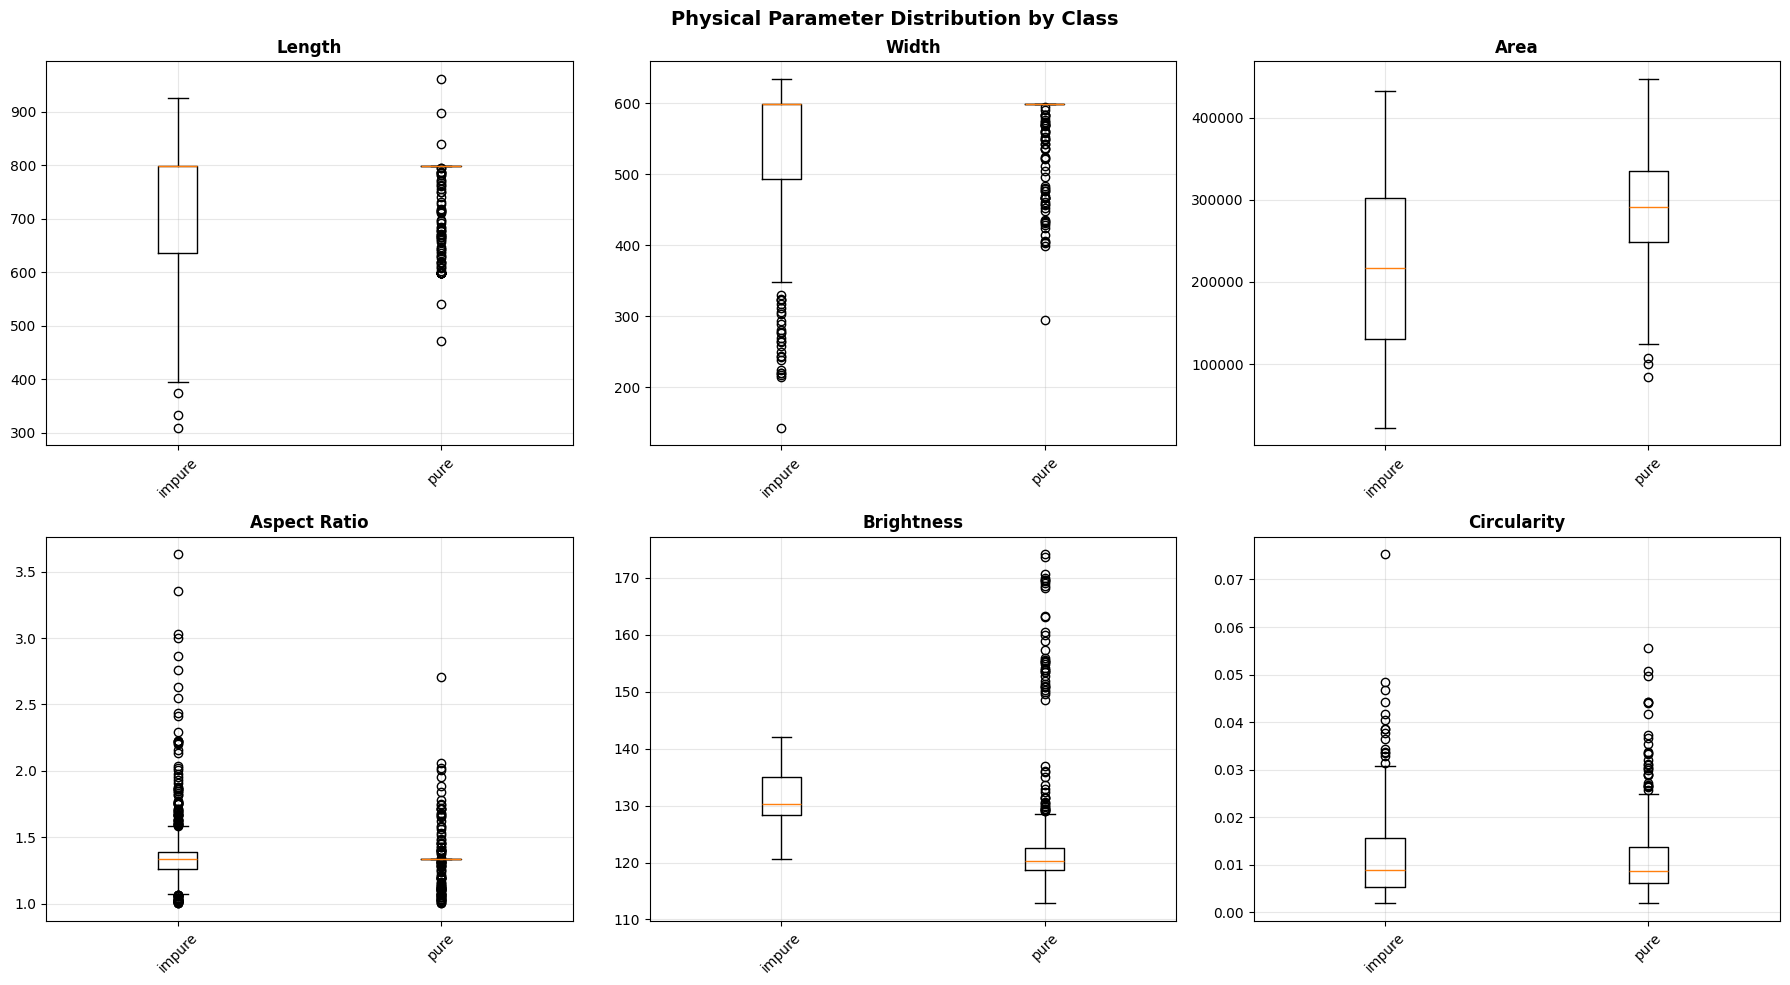

In [14]:
def analyze_physical_parameters():
    """Analyze and visualize physical parameters across classes."""
    print("\n" + "="*70)
    print("  PHYSICAL PARAMETER ANALYSIS BY CLASS")
    print("="*70)
    
    # Collect parameters by class
    class_params = {cls: defaultdict(list) for cls in CLASS_NAMES}
    
    for idx in range(len(train_dataset)):
        _, label, params = train_dataset[idx]
        class_name = CLASS_NAMES[label]
        for key, value in params.items():
            class_params[class_name][key].append(value)
    
    # Calculate statistics
    print(f"\n{'Parameter':<20} | {'Class':<30} | {'Mean':<12} | {'Std':<12}")
    print("-" * 80)
    
    key_params = ['length', 'width', 'area', 'aspect_ratio', 
                  'brightness', 'circularity']
    
    for param in key_params:
        for cls in CLASS_NAMES:
            values = class_params[cls][param]
            if values:
                mean_val = np.mean(values)
                std_val = np.std(values)
                print(f"{param:<20} | {cls:<30} | {mean_val:>10.2f} | {std_val:>10.2f}")
    
    # Visualize key parameters
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for idx, param in enumerate(key_params):
        data = [class_params[cls][param] for cls in CLASS_NAMES]
        axes[idx].boxplot(data, labels=CLASS_NAMES)
        axes[idx].set_title(f'{param.replace("_", " ").title()}', 
                           fontweight='bold')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].grid(alpha=0.3)
    
    plt.suptitle('Physical Parameter Distribution by Class', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("="*70)

analyze_physical_parameters()

In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 8 ── ResNet50 Model Builder
# ─────────────────────────────────────────────────────────────

In [16]:
def build_resnet50_model(num_classes=NUM_CLASSES, freeze_backbone=True):
    """
    Build ResNet50 model with transfer learning.
    Pre-trained on ImageNet with custom classification head.
    """
    print(f"\n🏗️  Building ResNet50 model...")
    
    # Load pre-trained ResNet50
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    
    # Freeze backbone if requested
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        print("    ✅  Backbone frozen (transfer learning)")
    
    # Replace classification head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Dropout(p=0.4),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )
    
    model = model.to(DEVICE)
    
    # Count parameters
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    
    print(f"    Architecture: ResNet50")
    print(f"    Trainable params: {trainable:,} / {total:,}")
    print(f"    Pre-trained: ImageNet")
    
    return model

# ── Build model
ARCHITECTURE = "resnet50"
model = build_resnet50_model(freeze_backbone=True)


🏗️  Building ResNet50 model...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 225MB/s]


    ✅  Backbone frozen (transfer learning)
    Architecture: ResNet50
    Trainable params: 1,182,466 / 24,690,498
    Pre-trained: ImageNet


In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 9 ── Training Configuration
# ─────────────────────────────────────────────────────────────

In [18]:
# ── Hyperparameters
LEARNING_RATE  = 1e-3
EPOCHS_FROZEN  = 5
EPOCHS_FINETUNE = 15   # reduced from 20; early stopping handles the rest
WEIGHT_DECAY   = 1e-4
SCHEDULER_STEP  = 7
SCHEDULER_GAMMA = 0.1

# ── Loss function
criterion = nn.CrossEntropyLoss()

# ── Optimizer
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ── Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer,
                                      step_size=SCHEDULER_STEP,
                                      gamma=SCHEDULER_GAMMA)

print("\n⚙️  Training Configuration:")
print(f"    Learning Rate: {LEARNING_RATE}")
print(f"    Batch Size: {BATCH_SIZE}")
print(f"    Phase 1 (Frozen): {EPOCHS_FROZEN} epochs")
print(f"    Phase 2 (Fine-tune): {EPOCHS_FINETUNE} epochs")
print(f"    Weight Decay: {WEIGHT_DECAY}")
print(f"    Optimizer: Adam")


⚙️  Training Configuration:
    Learning Rate: 0.001
    Batch Size: 32
    Phase 1 (Frozen): 5 epochs
    Phase 2 (Fine-tune): 15 epochs
    Weight Decay: 0.0001
    Optimizer: Adam


In [19]:
# ─────────────────────────────────────────────────────────────
# CELL 10 ── Training & Validation Functions
# ─────────────────────────────────────────────────────────────

In [20]:
def train_one_epoch(model, loader, criterion, optimizer):
    """Train for one epoch."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels, params in tqdm(loader, desc="  Training", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return running_loss / total, correct / total


def validate(model, loader, criterion):
    """Validate the model."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels, params in tqdm(loader, desc="  Validating", leave=False):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = running_loss / total
    accuracy = correct / total
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    
    return avg_loss, accuracy, prec, rec, f1


def run_training(model, epochs, phase_name="Training", patience=5):
    """
    Run training for specified epochs with early stopping.

    Early stopping (patience=5) prevents the model from memorising the
    training set after val accuracy plateaus — a key guard against the
    artificially perfect scores seen before.
    """
    best_acc = 0.0
    best_model = copy.deepcopy(model.state_dict())
    no_improve = 0   # counter for early stopping

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "precision": [], "recall": [], "f1": []
    }

    print(f"\n{'='*70}")
    print(f"  {phase_name}  |  Epochs: {epochs}  |  Patience: {patience}  |  Device: {DEVICE}")
    print(f"{'='*70}")

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, prec, rec, f1 = validate(model, val_loader, criterion)
        scheduler.step()
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        history["precision"].append(prec)
        history["recall"].append(rec)
        history["f1"].append(f1)

        lr_now = optimizer.param_groups[0]["lr"]
        print(f"  Epoch [{epoch:02d}/{epochs}]  "
              f"Loss: {tr_loss:.4f}/{vl_loss:.4f}  "
              f"Acc: {tr_acc*100:.1f}%/{vl_acc*100:.1f}%  "
              f"F1: {f1:.3f}  LR: {lr_now:.2e}  ({elapsed:.1f}s)")

        if vl_acc > best_acc:
            best_acc = vl_acc
            no_improve = 0
            best_model = copy.deepcopy(model.state_dict())
            torch.save(best_model, "best_resnet50_paddy_model.pth")
            print(f"    ✅  New best val accuracy: {best_acc*100:.2f}%")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"    ⏹  Early stopping triggered at epoch {epoch} "
                      f"(no val improvement for {patience} epochs)")
                break

    print(f"\n🏆  Best Validation Accuracy: {best_acc*100:.2f}%")
    model.load_state_dict(best_model)
    return history

In [21]:
# ─────────────────────────────────────────────────────────────
# CELL 11 ── Phase 1: Train Classification Head Only
# ─────────────────────────────────────────────────────────────

In [22]:
print("\n⏳  PHASE 1: Training classification head (backbone frozen)")
history_frozen = run_training(model, epochs=EPOCHS_FROZEN,
                             phase_name="Phase 1 — Head Training")


⏳  PHASE 1: Training classification head (backbone frozen)

  Phase 1 — Head Training  |  Epochs: 5  |  Patience: 5  |  Device: cuda


  Epoch [01/5]  Loss: 0.3400/0.4393  Acc: 85.1%/76.4%  F1: 0.754  LR: 1.00e-03  (13.0s)
    ✅  New best val accuracy: 76.37%


  Epoch [02/5]  Loss: 0.1642/0.2920  Acc: 92.6%/85.7%  F1: 0.856  LR: 1.00e-03  (12.5s)
    ✅  New best val accuracy: 85.71%


  Epoch [03/5]  Loss: 0.1543/0.3191  Acc: 94.7%/84.1%  F1: 0.838  LR: 1.00e-03  (12.2s)


  Epoch [04/5]  Loss: 0.1172/0.2293  Acc: 95.6%/87.4%  F1: 0.873  LR: 1.00e-03  (12.2s)
    ✅  New best val accuracy: 87.36%


  Epoch [05/5]  Loss: 0.1286/0.1485  Acc: 94.6%/94.0%  F1: 0.940  LR: 1.00e-03  (12.3s)
    ✅  New best val accuracy: 93.96%

🏆  Best Validation Accuracy: 93.96%


In [23]:
# ─────────────────────────────────────────────────────────────
# CELL 12 ── Phase 2: Fine-tune Entire Network
# ─────────────────────────────────────────────────────────────

In [24]:
print("\n⏳  PHASE 2: Fine-tuning entire ResNet50")

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE * 0.1,
    weight_decay=WEIGHT_DECAY
)

# CosineAnnealingLR gives a smooth, gradual decay over the fine-tune phase
# instead of abrupt step drops — better for avoiding overfitting on small data.
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_FINETUNE, eta_min=1e-6
)

history_finetune = run_training(model, epochs=EPOCHS_FINETUNE,
                                phase_name="Phase 2 — Full Fine-tuning",
                                patience=5)

# Merge histories
full_history = {k: history_frozen[k] + history_finetune[k]
                for k in history_frozen}


⏳  PHASE 2: Fine-tuning entire ResNet50

  Phase 2 — Full Fine-tuning  |  Epochs: 15  |  Patience: 5  |  Device: cuda


  Epoch [01/15]  Loss: 0.0624/0.0304  Acc: 97.4%/98.9%  F1: 0.989  LR: 9.89e-05  (14.0s)
    ✅  New best val accuracy: 98.90%


  Epoch [02/15]  Loss: 0.0658/0.0926  Acc: 97.6%/97.3%  F1: 0.973  LR: 9.57e-05  (14.0s)


  Epoch [03/15]  Loss: 0.0490/0.0136  Acc: 97.9%/100.0%  F1: 1.000  LR: 9.05e-05  (14.2s)
    ✅  New best val accuracy: 100.00%


  Epoch [04/15]  Loss: 0.0399/0.0093  Acc: 98.4%/100.0%  F1: 1.000  LR: 8.36e-05  (14.3s)


  Epoch [05/15]  Loss: 0.0279/0.0066  Acc: 99.1%/100.0%  F1: 1.000  LR: 7.52e-05  (15.2s)


  Epoch [06/15]  Loss: 0.0286/0.0059  Acc: 98.8%/100.0%  F1: 1.000  LR: 6.58e-05  (14.7s)


  Epoch [07/15]  Loss: 0.0479/0.0044  Acc: 98.2%/100.0%  F1: 1.000  LR: 5.57e-05  (15.1s)


  Epoch [08/15]  Loss: 0.0295/0.0063  Acc: 99.2%/100.0%  F1: 1.000  LR: 4.53e-05  (15.0s)
    ⏹  Early stopping triggered at epoch 8 (no val improvement for 5 epochs)

🏆  Best Validation Accuracy: 100.00%


In [25]:
# ─────────────────────────────────────────────────────────────
# CELL 13 ── Training Visualization
# ─────────────────────────────────────────────────────────────

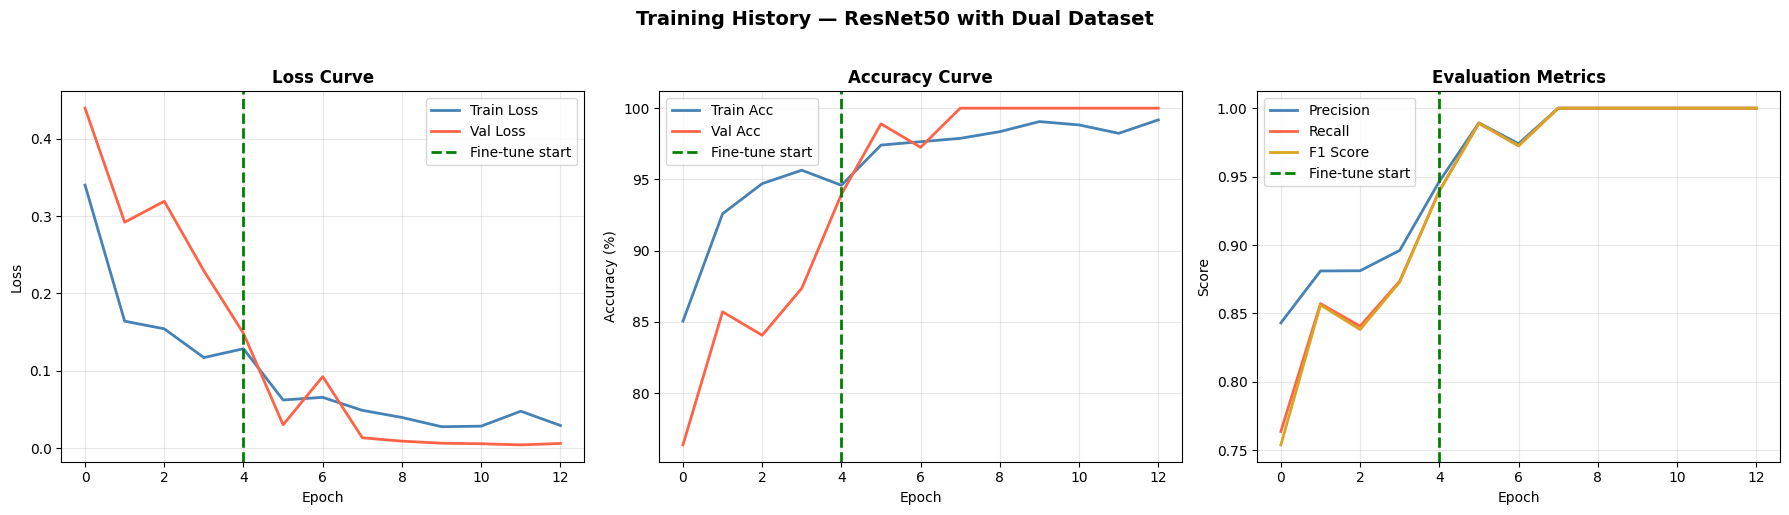

In [26]:
def plot_training_history(history):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(history["train_loss"], label="Train Loss", color="steelblue", linewidth=2)
    axes[0].plot(history["val_loss"], label="Val Loss", color="tomato", linewidth=2)
    axes[0].axvline(x=EPOCHS_FROZEN - 1, color="green",
                   linestyle="--", label="Fine-tune start", linewidth=2)
    axes[0].set_title("Loss Curve", fontweight="bold", fontsize=12)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Accuracy
    axes[1].plot([a*100 for a in history["train_acc"]], label="Train Acc",
                color="steelblue", linewidth=2)
    axes[1].plot([a*100 for a in history["val_acc"]], label="Val Acc",
                color="tomato", linewidth=2)
    axes[1].axvline(x=EPOCHS_FROZEN - 1, color="green",
                   linestyle="--", label="Fine-tune start", linewidth=2)
    axes[1].set_title("Accuracy Curve", fontweight="bold", fontsize=12)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Metrics
    axes[2].plot(history["precision"], label="Precision", color="steelblue", linewidth=2)
    axes[2].plot(history["recall"], label="Recall", color="tomato", linewidth=2)
    axes[2].plot(history["f1"], label="F1 Score", color="goldenrod", linewidth=2)
    axes[2].axvline(x=EPOCHS_FROZEN - 1, color="green",
                   linestyle="--", label="Fine-tune start", linewidth=2)
    axes[2].set_title("Evaluation Metrics", fontweight="bold", fontsize=12)
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Score")
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.suptitle(f"Training History — ResNet50 with Dual Dataset",
                fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_training_history(full_history)

In [27]:
# ─────────────────────────────────────────────────────────────
# CELL 14 ── Comprehensive Testing & Evaluation
# ─────────────────────────────────────────────────────────────


  COMPREHENSIVE TEST SET EVALUATION


Testing: 100%|██████████| 6/6 [00:02<00:00,  2.59it/s]



📊  CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      impure     1.0000    1.0000    1.0000        97
        pure     1.0000    1.0000    1.0000        85

    accuracy                         1.0000       182
   macro avg     1.0000    1.0000    1.0000       182
weighted avg     1.0000    1.0000    1.0000       182


🎯  OVERALL METRICS:
──────────────────────────────────────────────────────────────────────
  Accuracy   : 100.00%
  Precision  : 100.00%
  Recall     : 100.00%
  F1 Score   : 100.00%
──────────────────────────────────────────────────────────────────────

📈  PER-CLASS PERFORMANCE:
──────────────────────────────────────────────────────────────────────
Class                               Precision    Recall       F1-Score    
──────────────────────────────────────────────────────────────────────
impure                                  100.00%      100.00%      100.00%
pure                                    100.00%      100.00%      100.00%

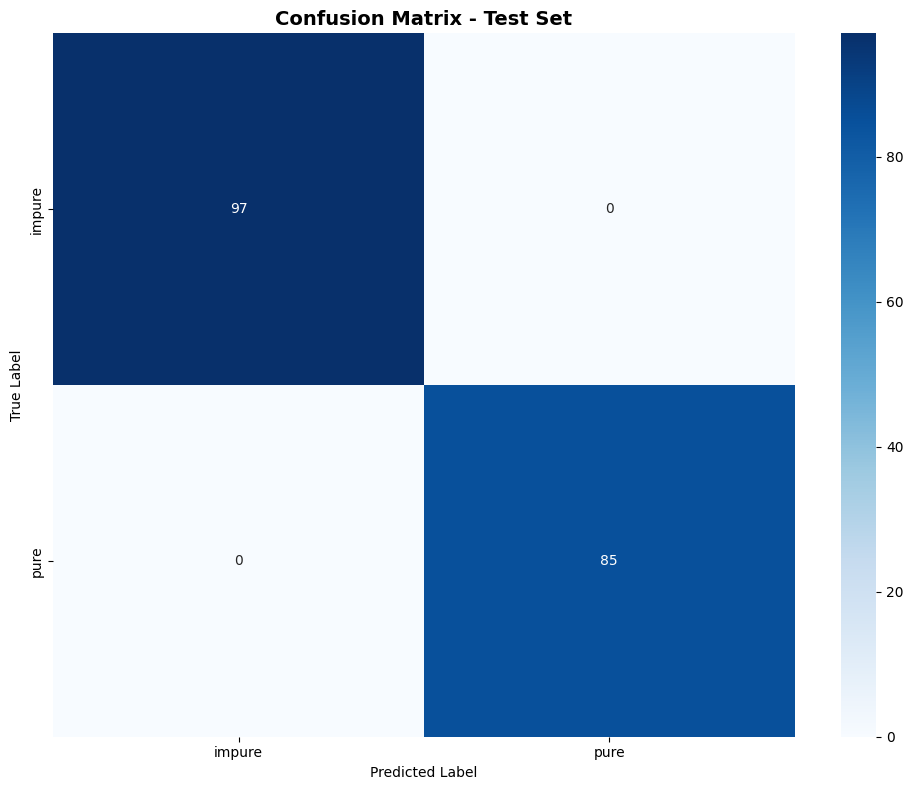


🔍  MISCLASSIFICATION ANALYSIS:
──────────────────────────────────────────────────────────────────────
  Total misclassifications: 0 / 182
  Misclassification rate: 0.00%
──────────────────────────────────────────────────────────────────────


In [28]:
def comprehensive_test_evaluation(model, test_loader):
    """Comprehensive test set evaluation with detailed metrics."""
    print("\n" + "="*70)
    print("  COMPREHENSIVE TEST SET EVALUATION")
    print("="*70)
    
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    all_params = defaultdict(list)
    
    with torch.no_grad():
        for images, labels, params in tqdm(test_loader, desc="Testing"):
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(probs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
            
            # Collect physical parameters
            for key, value in params.items():
                all_params[key].extend(value.numpy())
    
    # Classification Report
    print("\n📊  CLASSIFICATION REPORT:")
    print("="*70)
    print(classification_report(all_labels, all_preds,
                               target_names=CLASS_NAMES, digits=4))
    
    # Overall Metrics
    prec = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    
    print(f"\n🎯  OVERALL METRICS:")
    print(f"{'─'*70}")
    print(f"  Accuracy   : {acc*100:.2f}%")
    print(f"  Precision  : {prec*100:.2f}%")
    print(f"  Recall     : {rec*100:.2f}%")
    print(f"  F1 Score   : {f1*100:.2f}%")
    print(f"{'─'*70}")
    
    # Per-Class Metrics
    # BUG FIX: the original code passed [i]*len(class_labels) as y_true,
    # which is always a perfect match when class_preds also equals i —
    # that's why every class showed 100%.  Correct fix: use the full
    # all_labels / all_preds arrays with per-class labels parameter.
    print(f"\n📈  PER-CLASS PERFORMANCE:")
    print(f"{'─'*70}")
    print(f"{'Class':<35} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print(f"{'─'*70}")

    for i, cls in enumerate(CLASS_NAMES):
        cls_prec = precision_score(all_labels, all_preds, labels=[i],
                                   average='macro', zero_division=0)
        cls_rec  = recall_score(all_labels, all_preds, labels=[i],
                                average='macro', zero_division=0)
        cls_f1   = f1_score(all_labels, all_preds, labels=[i],
                            average='macro', zero_division=0)
        print(f"{cls:<35} {cls_prec*100:>10.2f}%  {cls_rec*100:>10.2f}%  {cls_f1*100:>10.2f}%")
    
    print(f"{'─'*70}")
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix - Test Set', fontweight='bold', fontsize=14)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    # Analyze misclassifications with physical parameters
    print(f"\n🔍  MISCLASSIFICATION ANALYSIS:")
    print(f"{'─'*70}")
    misclass_indices = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]
    print(f"  Total misclassifications: {len(misclass_indices)} / {len(all_labels)}")
    print(f"  Misclassification rate: {len(misclass_indices)/len(all_labels)*100:.2f}%")
    
    if misclass_indices:
        print(f"\n  Physical parameter analysis of misclassified samples:")
        for param in ['length', 'width', 'aspect_ratio', 'brightness']:
            correct_vals = [all_params[param][i] for i in range(len(all_labels))
                          if i not in misclass_indices]
            misclass_vals = [all_params[param][i] for i in misclass_indices]
            
            if correct_vals and misclass_vals:
                print(f"    {param:<20}: Correct μ={np.mean(correct_vals):.2f}  "
                      f"Misclass μ={np.mean(misclass_vals):.2f}")
    
    print(f"{'─'*70}")
    
    return all_labels, all_preds, np.array(all_probs)

# Run comprehensive testing
test_labels, test_preds, test_probs = comprehensive_test_evaluation(model, test_loader)

In [29]:
# ─────────────────────────────────────────────────────────────
# CELL 15 ── Model Predictions with Physical Parameters
# ─────────────────────────────────────────────────────────────

In [30]:
def predict_with_parameters(image_path, model, show_params=True):
    """
    Predict seed class and show physical parameters.
    """
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_tensor = eval_transforms(img).unsqueeze(0).to(DEVICE)
    
    # Extract physical parameters
    params = param_extractor.extract_parameters(image_path)
    
    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
        pred_class = CLASS_NAMES[pred_idx]
        pred_prob = probs[pred_idx].item()
    
    # Display results
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Show image
    axes[0].imshow(img)
    axes[0].set_title(f"Predicted: {pred_class}\nConfidence: {pred_prob*100:.1f}%",
                     fontweight='bold', fontsize=12)
    axes[0].axis('off')
    
    # Show probabilities
    bars = axes[1].barh(CLASS_NAMES, [probs[i].item()*100 for i in range(NUM_CLASSES)])
    axes[1].set_xlabel('Probability (%)')
    axes[1].set_title('Class Probabilities', fontweight='bold', fontsize=12)
    axes[1].set_xlim([0, 100])
    
    # Color the predicted class
    bars[pred_idx].set_color('green')
    
    plt.tight_layout()
    plt.show()
    
    # Show physical parameters if requested
    if show_params:
        print(f"\n{'='*70}")
        print(f"  PHYSICAL PARAMETERS")
        print(f"{'='*70}")
        print(f"  Dimensional:")
        print(f"    Length: {params['length']:.2f} px")
        print(f"    Width: {params['width']:.2f} px")
        print(f"    Area: {params['area']:.2f} px²")
        print(f"    Aspect Ratio: {params['aspect_ratio']:.2f}")
        print(f"\n  Color:")
        print(f"    Brightness: {params['brightness']:.2f}")
        print(f"    Mean RGB: ({params['mean_red']:.1f}, "
              f"{params['mean_green']:.1f}, {params['mean_blue']:.1f})")
        print(f"\n  Shape:")
        print(f"    Circularity: {params['circularity']:.3f}")
        print(f"    Solidity: {params['solidity']:.3f}")
        print(f"{'='*70}")
    
    return {
        'prediction': pred_class,
        'confidence': pred_prob,
        'probabilities': {CLASS_NAMES[i]: probs[i].item() 
                         for i in range(NUM_CLASSES)},
        'physical_parameters': params
    }

In [31]:
# ─────────────────────────────────────────────────────────────
# CELL 16 ── Save Model and Generate Summary Report
# ─────────────────────────────────────────────────────────────

In [32]:
def save_model(model, path="resnet50_paddy_dual_dataset.pth"):
    """Save the trained model."""
    torch.save({
        "architecture": ARCHITECTURE,
        "num_classes": NUM_CLASSES,
        "class_names": CLASS_NAMES,
        "state_dict": model.state_dict(),
        "train_history": full_history,
    }, path)
    print(f"✅  Model saved to: {path}")


def generate_summary_report():
    """Generate comprehensive training summary."""
    print("\n" + "█"*70)
    print("  PADDY SEED DETECTION — FINAL SUMMARY REPORT")
    print("  ResNet50 with Dual Dataset & Physical Parameters")
    print("█"*70)
    
    print(f"\n{'─'*70}")
    print(f"  MODEL ARCHITECTURE")
    print(f"{'─'*70}")
    print(f"  Architecture       : ResNet50")
    print(f"  Input Resolution   : {IMAGE_SIZE} × {IMAGE_SIZE} pixels")
    print(f"  Transfer Learning  : ✅  Pre-trained on ImageNet")
    print(f"  Classes            : {NUM_CLASSES}")
    for i, c in enumerate(CLASS_NAMES):
        print(f"    [{i}] {c}")
    
    print(f"\n{'─'*70}")
    print(f"  DATASET CONFIGURATION")
    print(f"{'─'*70}")
    print(f"  Source 1           : ayyanarkadalkani/paddy-seeds-quality")
    print(f"  Source 2           : Paddy Seed Image Dataset")
    print(f"  Combined Training  : {len(train_dataset)} images")
    print(f"  Validation Set     : {len(val_dataset)} images")
    print(f"  Test Set           : {len(test_dataset)} images")
    
    print(f"\n{'─'*70}")
    print(f"  PHYSICAL PARAMETERS EXTRACTED")
    print(f"{'─'*70}")
    print(f"  Dimensional        : Length, Width, Area, Perimeter, Aspect Ratio")
    print(f"  Color Features     : Mean RGB, Std RGB, Brightness")
    print(f"  Shape Descriptors  : Circularity, Solidity, Convexity")
    print(f"  Texture Features   : Variance, Entropy")
    
    print(f"\n{'─'*70}")
    print(f"  TRAINING CONFIGURATION")
    print(f"{'─'*70}")
    print(f"  Optimizer          : Adam")
    print(f"  Initial LR         : {LEARNING_RATE}")
    print(f"  Fine-tune LR       : {LEARNING_RATE * 0.1}")
    print(f"  Batch Size         : {BATCH_SIZE}")
    print(f"  Phase-1 Epochs     : {EPOCHS_FROZEN} (head only, early-stopped)")
    print(f"  Phase-2 Epochs     : {EPOCHS_FINETUNE} (full fine-tune, early-stopped)")
    print(f"  Total Epochs (max) : {EPOCHS_FROZEN + EPOCHS_FINETUNE}")
    print(f"  Weight Decay       : {WEIGHT_DECAY}")
    print(f"  Data Augmentation  : Flip, Rotate, Crop, ColorJitter, Affine")
    
    print(f"\n{'─'*70}")
    print(f"  FINAL TEST METRICS")
    print(f"{'─'*70}")
    acc = accuracy_score(test_labels, test_preds)
    prec = precision_score(test_labels, test_preds, average="weighted", zero_division=0)
    rec = recall_score(test_labels, test_preds, average="weighted", zero_division=0)
    f1 = f1_score(test_labels, test_preds, average="weighted", zero_division=0)
    
    print(f"  Accuracy           : {acc*100:.2f}%")
    print(f"  Precision          : {prec*100:.2f}%")
    print(f"  Recall             : {rec*100:.2f}%")
    print(f"  F1 Score           : {f1*100:.2f}%")
    
    print("\n" + "█"*70 + "\n")

# Save model and generate report
save_model(model)
generate_summary_report()

✅  Model saved to: resnet50_paddy_dual_dataset.pth

██████████████████████████████████████████████████████████████████████
  PADDY SEED DETECTION — FINAL SUMMARY REPORT
  ResNet50 with Dual Dataset & Physical Parameters
██████████████████████████████████████████████████████████████████████

──────────────────────────────────────────────────────────────────────
  MODEL ARCHITECTURE
──────────────────────────────────────────────────────────────────────
  Architecture       : ResNet50
  Input Resolution   : 224 × 224 pixels
  Transfer Learning  : ✅  Pre-trained on ImageNet
  Classes            : 2
    [0] impure
    [1] pure

──────────────────────────────────────────────────────────────────────
  DATASET CONFIGURATION
──────────────────────────────────────────────────────────────────────
  Source 1           : ayyanarkadalkani/paddy-seeds-quality
  Source 2           : Paddy Seed Image Dataset
  Combined Training  : 850 images
  Validation Set     : 182 images
  Test Set           : 182 